# AFMLF Unseen Container Case Study

**Deployment demonstration — not a new research experiment.**

This notebook teaches AFMLF as **two distinct levels**:

| Level | What it covers |
|-------|----------------|
| **Individual container monitoring** | Forecast → rolling errors → drift → diagnostics |
| **Global model lifecycle** | Cohort aggregation → trigger policy → offline retrain → deployment recommendation |

The deployed Hybrid model is a **global model** trained across many containers. A single drifting unseen container does **not** retrain it — only cohort-level evidence can.

> **Incumbent:** `hybrid_v1` from official experiment (read-only)

**Kernel required:** `tf_metal_env`. One-time setup:
```bash
tf_metal_env/bin/python -m ipykernel install --user --name=tf_metal_env --display-name='tf_metal_env'
```

## 1. Introduction

The official AFMLF evaluation proved lifecycle governance at thesis scale (99 containers). This notebook complements it in two parts:

1. **Section 2** — Individual container monitoring on two unseen workloads (stable vs drifting)
2. **Section 3** — Cohort-level lifecycle using the **official 99-container experiment**
3. **Section 4** — How the two levels differ, with an architecture diagram

No AFMLF methodology is changed. All figures are generated live from data.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display, Markdown
except ImportError:
    display = print
    Markdown = print

REPO = Path('..').resolve()
sys.path.insert(0, str(REPO))

from utils.adaptive_lifecycle import plots as afmlf_plots
from utils.adaptive_lifecycle.config import AFMLFConfig, DeploymentRecommendation
from utils.adaptive_lifecycle.candidate_retraining import load_model_bundle
from utils.adaptive_lifecycle.diagnostics import DiagnosticClass, classify_container
from utils.adaptive_lifecycle.drift_detection import detect_container_drift, drift_threshold
from utils.adaptive_lifecycle.monitoring import (
    build_container_series,
    forecast_at_origin,
    generate_origin_indices,
)
from utils.adaptive_lifecycle.rolling_metrics import append_rolling_metrics

OFFICIAL_EXP = [p for p in sorted(REPO.glob('experiments/adaptive_forecast_model_lifecycle_*')) if (p / 'OFFICIAL_RUN').exists()][-1]
CASE_OUT = REPO / 'notebooks' / 'outputs' / 'afmlf_case_study'
CASE_OUT.mkdir(parents=True, exist_ok=True)
SCAN_CSV = CASE_OUT / 'unseen_scan.csv'

CFG = AFMLFConfig.from_json(OFFICIAL_EXP / 'config' / 'afmlf_config.json')
COHORT = set(pd.read_csv(REPO / CFG.baseline_evaluation_csv)['container_id'])
train_df = pd.read_parquet(REPO / CFG.train_df_path)
val_df = pd.read_parquet(REPO / CFG.val_df_path)

with (REPO / 'production/hybrid/metadata/unseen_container_ids.json').open() as fh:
    UNSEEN_IDS = json.load(fh)['container_ids']
UNSEEN_IDS = [c for c in UNSEEN_IDS if c not in COHORT]
available = [c for c in UNSEEN_IDS if c in set(train_df['container_id']) | set(val_df['container_id'])]

INCUMBENT_DIR = OFFICIAL_EXP / 'versions' / 'hybrid_v1'
incumbent, res_mean, res_std = load_model_bundle(INCUMBENT_DIR)
RESCAN_CONTAINERS = False  # set True to rerun full unseen scan (~1 min)

print('Python:', sys.executable)
print('Official experiment:', OFFICIAL_EXP.name)
print('Unseen containers in dataset:', len(available))

Importing plotly failed. Interactive plots will not work.
2026-08-03 09:17:55.717471: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-08-03 09:17:55.717523: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-08-03 09:17:55.717529: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-08-03 09:17:55.717547: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-03 09:17:55.717557: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Python: /Users/lehaan/Desktop/FYP_Long_Term/tf_metal_env/bin/python
Official experiment: adaptive_forecast_model_lifecycle_2026-07-30_071206
Unseen containers in dataset: 36


In [2]:
def forecast_detail(series, origin, model, res_mean, res_std, config):
    from sklearn.preprocessing import MinMaxScaler
    from prophet import Prophet
    history = series.iloc[:origin].copy()
    future = series.iloc[origin:origin + config.forecast_horizon].copy()
    scaler = MinMaxScaler(feature_range=(0, 1))
    history['cpu_scaled'] = scaler.fit_transform(history[['cpu']])
    future['cpu_scaled'] = scaler.transform(future[['cpu']])
    prophet_train = pd.DataFrame({'ds': history['time_stamp'], 'y': history['cpu_scaled']})
    pm = Prophet(daily_seasonality=True, weekly_seasonality=False)
    pm.fit(prophet_train)
    fc = pm.predict(pd.DataFrame({'ds': future['time_stamp']}))
    train_fc = pm.predict(prophet_train[['ds']])
    history['prophet_pred'] = train_fc['yhat'].values
    history['residual_scaled'] = (history['cpu_scaled'] - history['prophet_pred'] - res_mean) / res_std
    X = history['residual_scaled'].values[-config.input_window:].reshape(1, config.input_window, 1)
    day1_res = (model.predict(X, verbose=0)[0] * res_std) + res_mean
    hybrid_scaled = fc['yhat'].values + day1_res
    actual = scaler.inverse_transform(future[['cpu_scaled']]).ravel()
    hybrid = scaler.inverse_transform(hybrid_scaled.reshape(-1, 1)).ravel()
    prophet_only = scaler.inverse_transform(fc['yhat'].values.reshape(-1, 1)).ravel()
    return future['time_stamp'], actual, hybrid, prophet_only


def monitor_unseen_container(container_id: str) -> dict:
    """Container-level monitoring only — no global retraining."""
    series = build_container_series(train_df, val_df, container_id)
    origins = generate_origin_indices(len(series), CFG)
    rows = [forecast_at_origin(series, origin, incumbent, res_mean, res_std, CFG).__dict__ for origin in origins]
    monitor_df = append_rolling_metrics(pd.DataFrame(rows), CFG.rolling_window_origins)
    monitor_df['container_id'] = container_id
    deploy_baseline_mae = float(monitor_df.iloc[0]['hybrid_mae'])
    deploy_baseline_prophet = float(monitor_df.iloc[0]['prophet_mae'])
    threshold = drift_threshold(deploy_baseline_mae, CFG.relative_threshold, CFG.absolute_threshold)
    drift_rows, diag_rows = [], []
    for _, r in monitor_df.iterrows():
        drift_rows.append(detect_container_drift(
            container_id, int(r.origin_index), r.rolling_hybrid_mae, deploy_baseline_mae, CFG
        ).__dict__)
        diag_rows.append(classify_container(
            container_id, int(r.origin_index), r.rolling_hybrid_mae, r.rolling_prophet_mae,
            deploy_baseline_mae, deploy_baseline_prophet, CFG,
        ))
    drift_df = pd.DataFrame(drift_rows)
    breaches = drift_df['threshold_breach']
    first_breach = int(drift_df.loc[breaches].iloc[0]['origin_index']) if breaches.any() else None
    trigger_diag = next((d.diagnostic_class.value for d in diag_rows if d.origin_index == first_breach), None)
    return {
        'container_id': container_id,
        'series': series,
        'origins': origins,
        'monitor_df': monitor_df,
        'drift_df': drift_df,
        'diag_rows': diag_rows,
        'deploy_baseline_mae': deploy_baseline_mae,
        'threshold': threshold,
        'n_breaches': int(breaches.sum()),
        'first_breach_origin': first_breach,
        'trigger_diagnostic': trigger_diag,
        'max_rolling_mae': float(monitor_df['rolling_hybrid_mae'].max()),
        'headroom': float(threshold - monitor_df['rolling_hybrid_mae'].max()),
        'n_stable_diag': sum(1 for d in diag_rows if d.diagnostic_class == DiagnosticClass.STABLE),
        'n_origins': len(origins),
    }


def container_monitoring_summary(result: dict) -> dict:
    drift = result['n_breaches'] > 0
    if drift:
        action = 'added_to_drift_registry'
        deploy_rec = 'keep_current_model (container-level; await cohort trigger)'
        explain = (
            'Degradation detected for this container. Registered in drift evidence. '
            'Does NOT retrain the global Hybrid model alone.'
        )
    else:
        action = 'no_action'
        deploy_rec = DeploymentRecommendation.KEEP_CURRENT_MODEL.value
        explain = 'Monitoring within thresholds; no drift; keep hybrid_v1 for this container.'
    return {
        'container_id': result['container_id'],
        'max_rolling_mae': round(result['max_rolling_mae'], 3),
        'threshold': round(result['threshold'], 3),
        'drift_detected': drift,
        'dominant_diagnostic': result['trigger_diagnostic'] or 'STABLE',
        'container_action': action,
        'global_retrain_triggered': False,
        'deployment_recommendation': deploy_rec,
        'explanation': explain,
    }

## 2. Individual Container Monitoring

This section demonstrates **operational monitoring** for newly deployed unseen containers. Each container is monitored independently against its own deployment baseline.

**Important:** outcomes here are **container-level only**. They feed the drift registry but do **not** directly trigger global model retraining.

In [3]:
if RESCAN_CONTAINERS or not SCAN_CSV.exists():
    print('Scanning unseen containers...')
    scan_rows = []
    for i, cid in enumerate(available, 1):
        print(f'  [{i}/{len(available)}] {cid}')
        s = monitor_unseen_container(cid)
        scan_rows.append({k: s[k] for k in s if k not in {'series', 'origins', 'monitor_df', 'drift_df', 'diag_rows'}})
    scan_df = pd.DataFrame(scan_rows)
    scan_df.to_csv(SCAN_CSV, index=False)
else:
    scan_df = pd.read_csv(SCAN_CSV)
    print('Loaded cached scan:', SCAN_CSV.name)

stable_pool = scan_df[(scan_df['n_breaches'] == 0) & (scan_df['n_stable_diag'] == scan_df['n_origins'])]
stable_pool = stable_pool.sort_values(['headroom', 'deploy_baseline_mae'], ascending=[False, True])
STABLE_ID = stable_pool.iloc[0]['container_id']

drift_pool = scan_df[scan_df['n_breaches'] > 0].copy()
drift_pool['score'] = (
    drift_pool['n_breaches'] * 2 + drift_pool['max_consecutive_breaches'].fillna(0)
    + drift_pool['n_recommend_diag'].fillna(0)
    + drift_pool['trigger_diagnostic'].map({'REGIME_CHANGE': 3, 'GRU_STALE': 2, 'INVESTIGATE': 1}).fillna(0)
)
DRIFTED_ID = drift_pool.sort_values('score', ascending=False).iloc[0]['container_id']

print('Scenario A (stable):', STABLE_ID)
print('Scenario B (drifting):', DRIFTED_ID)

Loaded cached scan: unseen_scan.csv
Scenario A (stable): c_39702
Scenario B (drifting): c_29580


### Scenario A — Stable unseen container

Forecast → monitoring → rolling MAE/RMSE → **no drift** → diagnostics = STABLE → keep current model.

In [4]:
A = monitor_unseen_container(STABLE_ID)
summary_a = container_monitoring_summary(A)
print('Container:', STABLE_ID)
print('Breaches:', A['n_breaches'], '| Max rolling MAE:', round(A['max_rolling_mae'], 3))

09:17:56 - cmdstanpy - INFO - Chain [1] start processing
09:17:56 - cmdstanpy - INFO - Chain [1] done processing
2026-08-03 09:17:56.412544: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
09:17:56 - cmdstanpy - INFO - Chain [1] start processing
09:17:56 - cmdstanpy - INFO - Chain [1] done processing
09:17:56 - cmdstanpy - INFO - Chain [1] start processing
09:17:56 - cmdstanpy - INFO - Chain [1] done processing
09:17:56 - cmdstanpy - INFO - Chain [1] start processing
09:17:56 - cmdstanpy - INFO - Chain [1] done processing
09:17:57 - cmdstanpy - INFO - Chain [1] start processing
09:17:57 - cmdstanpy - INFO - Chain [1] done processing


Container: c_39702
Breaches: 0 | Max rolling MAE: 4.537


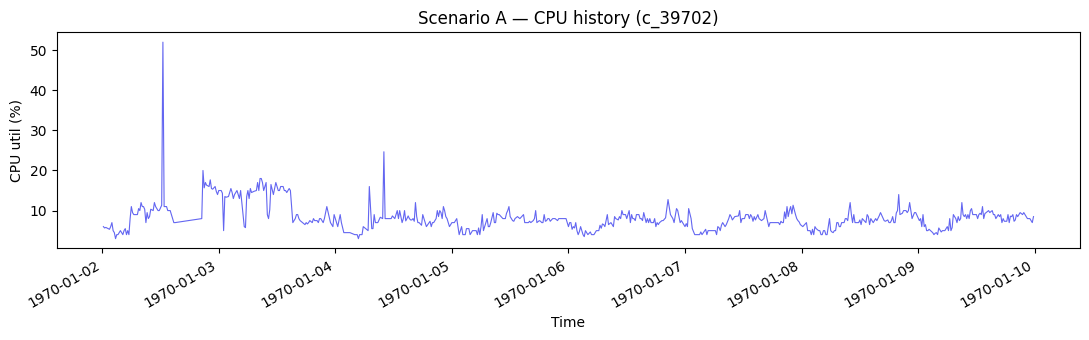

09:17:57 - cmdstanpy - INFO - Chain [1] start processing
09:17:57 - cmdstanpy - INFO - Chain [1] done processing


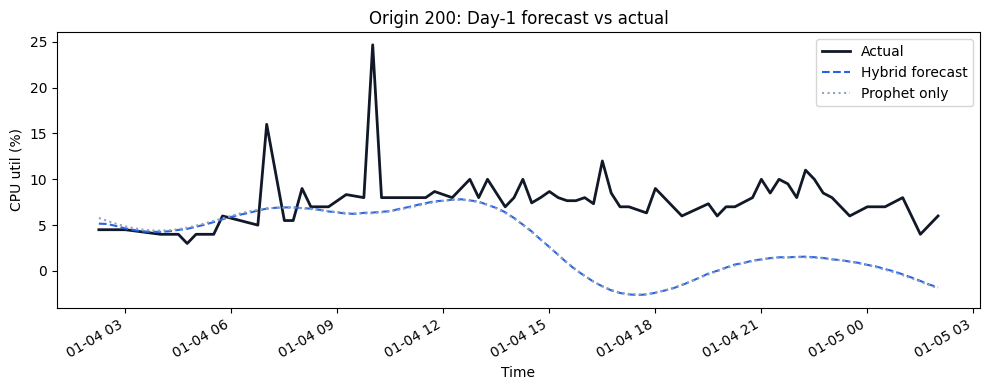

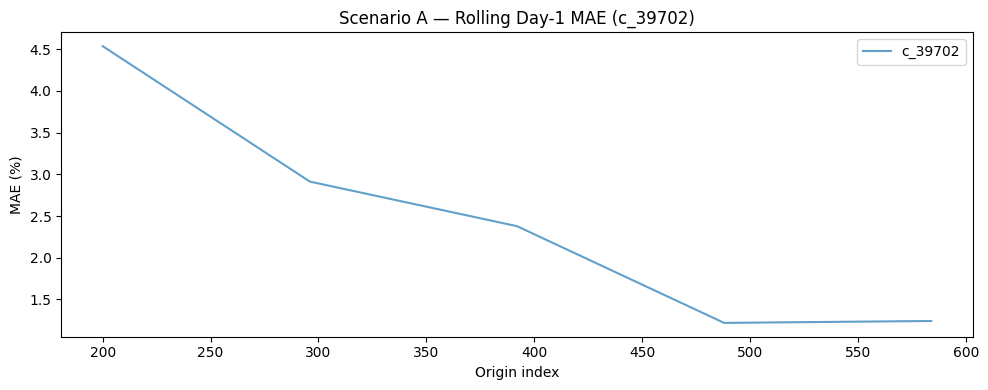

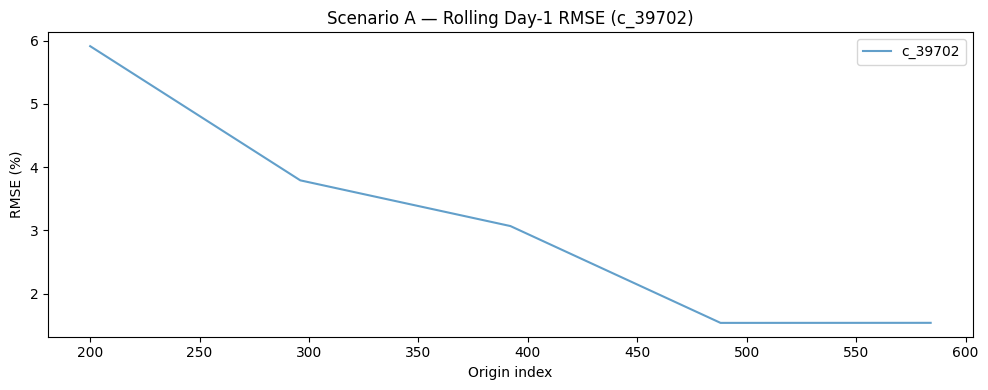

,origin_index,rolling_hybrid_mae,threshold_value,threshold_breach
0,200,4.536616,5.670769,False
1,296,2.912814,5.670769,False
2,392,2.378422,5.670769,False
3,488,1.218756,5.670769,False
4,584,1.241539,5.670769,False


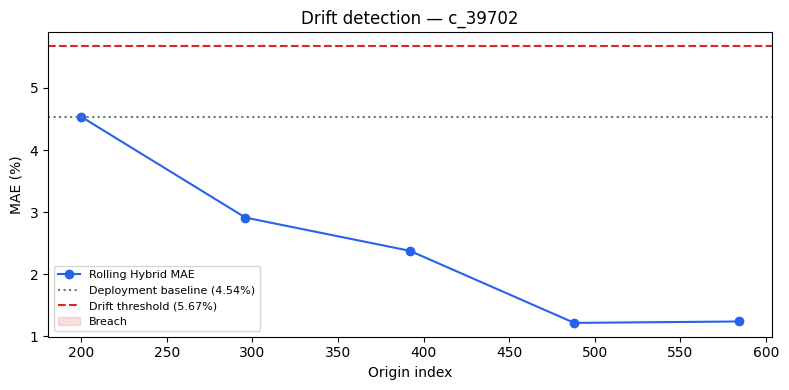

,origin_index,class,interpretation
0,200,STABLE,No significant diagnostic degradation detected.
1,296,STABLE,No significant diagnostic degradation detected.
2,392,STABLE,No significant diagnostic degradation detected.
3,488,STABLE,No significant diagnostic degradation detected.
4,584,STABLE,No significant diagnostic degradation detected.


CONTAINER ACTION: no_action
DEPLOYMENT (container-level): keep_current_model
Monitoring within thresholds; no drift; keep hybrid_v1 for this container.


In [5]:
fig, ax = afmlf_plots.plot_cpu_history(A['series'], title=f'Scenario A — CPU history ({STABLE_ID})')
plt.show()

first_origin = A['origins'][0]
ts, actual, hybrid, prophet = forecast_detail(A['series'], first_origin, incumbent, res_mean, res_std, CFG)
fig, ax = afmlf_plots.plot_forecast_origin(ts, actual, hybrid, prophet, title=f'Origin {first_origin}: Day-1 forecast vs actual')
plt.show()

fig, ax = afmlf_plots.plot_rolling_mae(A['monitor_df'], STABLE_ID)
ax.set_title(f'Scenario A — Rolling Day-1 MAE ({STABLE_ID})')
plt.show()
fig, ax = afmlf_plots.plot_rolling_rmse(A['monitor_df'], STABLE_ID)
ax.set_title(f'Scenario A — Rolling Day-1 RMSE ({STABLE_ID})')
plt.show()

display(A['drift_df'][['origin_index','rolling_hybrid_mae','threshold_value','threshold_breach']])
fig, ax = afmlf_plots.plot_drift_threshold(A['monitor_df'], STABLE_ID, A['deploy_baseline_mae'], A['threshold'])
plt.show()

diag_a = pd.DataFrame([{'origin_index': d.origin_index, 'class': d.diagnostic_class.value, 'interpretation': d.interpretation} for d in A['diag_rows']])
display(diag_a)
print('CONTAINER ACTION: no_action')
print('DEPLOYMENT (container-level): keep_current_model')
print(summary_a['explanation'])

### Scenario B — Drifting unseen container

Forecast → monitoring → rolling MAE/RMSE → **threshold breach** → diagnostics (REGIME_CHANGE / GRU_STALE) → **container added to drift registry**.

**Stop here.** Individual container degradation alone does **not** retrain the global Hybrid model.

In [6]:
B = monitor_unseen_container(DRIFTED_ID)
summary_b = container_monitoring_summary(B)
TRIGGER_B = B['first_breach_origin']
print('Container:', DRIFTED_ID)
print('First breach origin:', TRIGGER_B)
print('Trigger diagnostic:', B['trigger_diagnostic'])

09:17:58 - cmdstanpy - INFO - Chain [1] start processing
09:17:58 - cmdstanpy - INFO - Chain [1] done processing
09:17:58 - cmdstanpy - INFO - Chain [1] start processing
09:17:58 - cmdstanpy - INFO - Chain [1] done processing
09:17:58 - cmdstanpy - INFO - Chain [1] start processing
09:17:58 - cmdstanpy - INFO - Chain [1] done processing
09:17:58 - cmdstanpy - INFO - Chain [1] start processing
09:17:58 - cmdstanpy - INFO - Chain [1] done processing
09:17:58 - cmdstanpy - INFO - Chain [1] start processing
09:17:58 - cmdstanpy - INFO - Chain [1] done processing


Container: c_29580
First breach origin: 296
Trigger diagnostic: REGIME_CHANGE


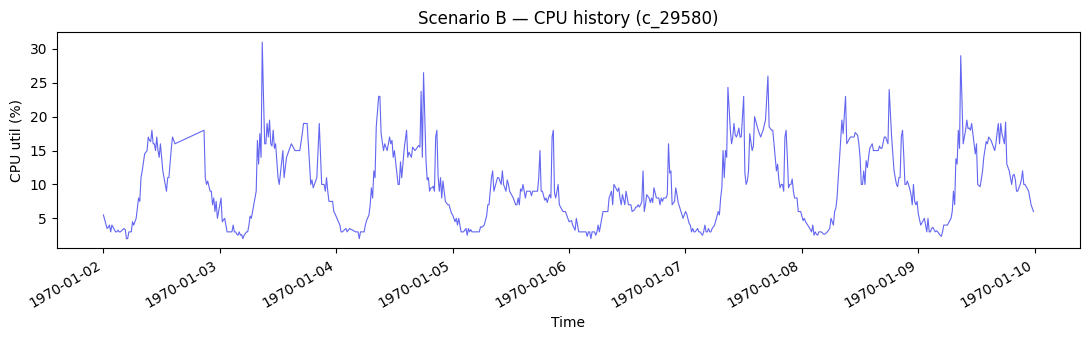

09:17:59 - cmdstanpy - INFO - Chain [1] start processing
09:17:59 - cmdstanpy - INFO - Chain [1] done processing


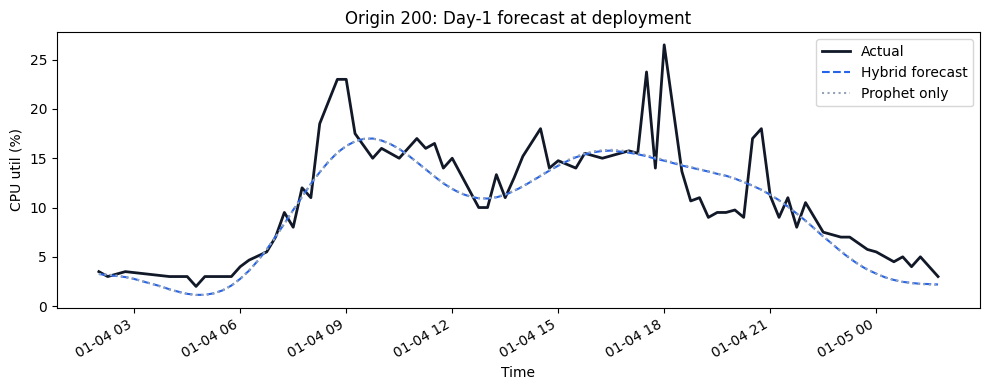

09:17:59 - cmdstanpy - INFO - Chain [1] start processing
09:17:59 - cmdstanpy - INFO - Chain [1] done processing


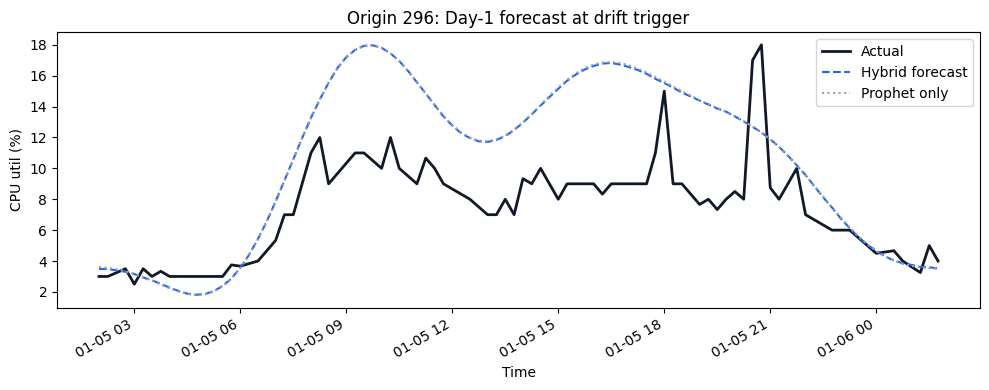

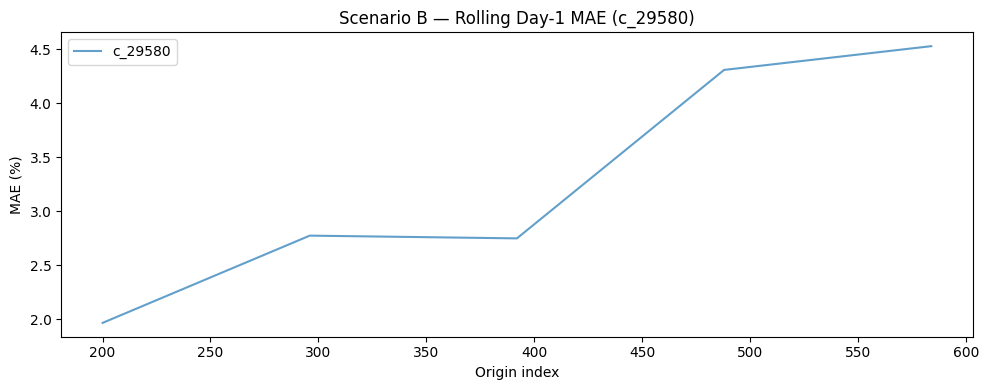

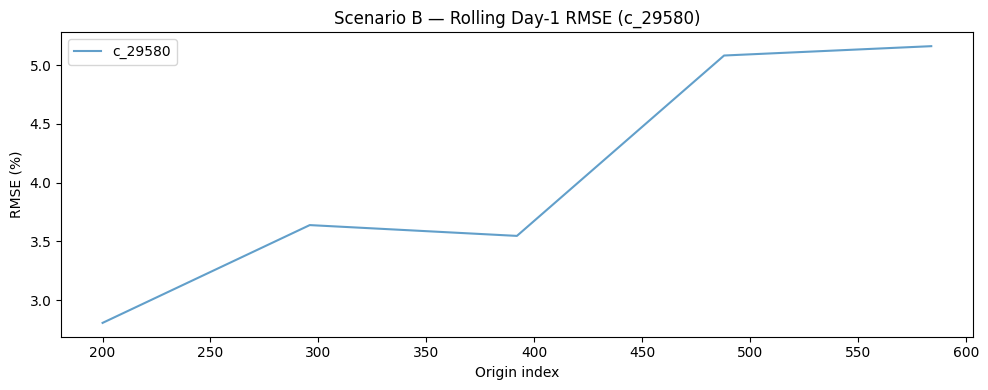

,origin_index,rolling_hybrid_mae,threshold_value,threshold_breach
0,200,1.966167,2.466167,False
1,296,2.773850,2.466167,True
2,392,2.748423,2.466167,True
3,488,4.307680,2.466167,True
4,584,4.527595,2.466167,True


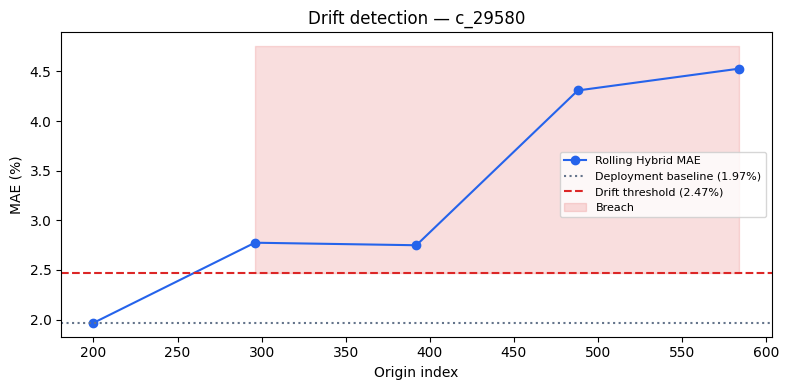

In [7]:
fig, ax = afmlf_plots.plot_cpu_history(B['series'], title=f'Scenario B — CPU history ({DRIFTED_ID})')
plt.show()

first_origin = B['origins'][0]
ts0, actual0, hybrid0, prophet0 = forecast_detail(B['series'], first_origin, incumbent, res_mean, res_std, CFG)
fig, ax = afmlf_plots.plot_forecast_origin(ts0, actual0, hybrid0, prophet0, title=f'Origin {first_origin}: Day-1 forecast at deployment')
plt.show()

ts_t, actual_t, hybrid_t, prophet_t = forecast_detail(B['series'], TRIGGER_B, incumbent, res_mean, res_std, CFG)
fig, ax = afmlf_plots.plot_forecast_origin(ts_t, actual_t, hybrid_t, prophet_t, title=f'Origin {TRIGGER_B}: Day-1 forecast at drift trigger')
plt.show()

fig, ax = afmlf_plots.plot_rolling_mae(B['monitor_df'], DRIFTED_ID)
ax.set_title(f'Scenario B — Rolling Day-1 MAE ({DRIFTED_ID})')
plt.show()
fig, ax = afmlf_plots.plot_rolling_rmse(B['monitor_df'], DRIFTED_ID)
ax.set_title(f'Scenario B — Rolling Day-1 RMSE ({DRIFTED_ID})')
plt.show()

display(B['drift_df'][['origin_index','rolling_hybrid_mae','threshold_value','threshold_breach']])
fig, ax = afmlf_plots.plot_drift_threshold(B['monitor_df'], DRIFTED_ID, B['deploy_baseline_mae'], B['threshold'])
plt.show()

In [8]:
diag_b = pd.DataFrame([{
    'origin_index': d.origin_index,
    'class': d.diagnostic_class.value,
    'interpretation': d.interpretation,
    'recommended_action': d.recommended_action,
} for d in B['diag_rows']])
display(diag_b)
trigger_row = diag_b.loc[diag_b['origin_index'] == TRIGGER_B].iloc[0]
print('At trigger:', trigger_row['class'], '—', trigger_row['interpretation'])

drift_registry_entry = pd.DataFrame([{
    'container_id': DRIFTED_ID,
    'first_breach_origin': TRIGGER_B,
    'diagnostic_class': trigger_row['class'],
    'registry_status': 'awaiting_cohort_evaluation',
    'global_retrain_triggered': False,
}])
display(drift_registry_entry)

print('\n' + '='*72)
print('CONTAINER-LEVEL OUTCOME (Scenario B)')
print('='*72)
print(
    f"The framework has identified degradation for container {DRIFTED_ID} "
    f"({trigger_row['class']} at origin {TRIGGER_B}).\n\n"
    'This alone is NOT sufficient to retrain the global Hybrid model.\n'
    'The container is now part of the monitored population awaiting cohort-level lifecycle evaluation.'
)

,origin_index,class,interpretation,recommended_action
0,200,STABLE,No significant diagnostic degradation detected.,no_action
1,296,REGIME_CHANGE,Both Hybrid and Prophet errors increased; unde...,recommend_retraining
2,392,REGIME_CHANGE,Both Hybrid and Prophet errors increased; unde...,recommend_retraining
3,488,REGIME_CHANGE,Both Hybrid and Prophet errors increased; unde...,recommend_retraining
4,584,REGIME_CHANGE,Both Hybrid and Prophet errors increased; unde...,recommend_retraining


At trigger: REGIME_CHANGE — Both Hybrid and Prophet errors increased; underlying workload regime likely changed.


,container_id,first_breach_origin,diagnostic_class,registry_status,global_retrain_triggered
0,c_29580,296,REGIME_CHANGE,awaiting_cohort_evaluation,False



CONTAINER-LEVEL OUTCOME (Scenario B)
The framework has identified degradation for container c_29580 (REGIME_CHANGE at origin 296).

This alone is NOT sufficient to retrain the global Hybrid model.
The container is now part of the monitored population awaiting cohort-level lifecycle evaluation.


### Container-level comparison

Both scenarios use the same global `hybrid_v1` model. Neither unseen container alone triggers retraining.

In [9]:
container_comparison = pd.DataFrame([summary_a, summary_b])
container_comparison.insert(0, 'scenario', ['A — Stable', 'B — Drifting'])
display(container_comparison.T)

,0,1
scenario,A — Stable,B — Drifting
container_id,c_39702,c_29580
max_rolling_mae,4.537,4.528
threshold,5.671,2.466
drift_detected,False,True
dominant_diagnostic,STABLE,REGIME_CHANGE
container_action,no_action,added_to_drift_registry
global_retrain_triggered,False,False
deployment_recommendation,keep_current_model,keep_current_model (container-level; await coh...
explanation,Monitoring within thresholds; no drift; keep h...,Degradation detected for this container. Regis...


## 3. How AFMLF Decides to Retrain the Global Model

Offline candidate retraining is a **cohort-level** decision. This section uses the **official 99-container AFMLF evaluation** — frozen results, not re-run.

Pipeline:

```
99 monitored containers
  → container-level monitoring
  → aggregate drift evidence
  → global trigger policy
  → offline candidate retraining
  → candidate evaluation
  → deployment recommendation
```

In [10]:
life = pd.read_csv(OFFICIAL_EXP / 'lifecycle/transitions.csv')
decisions = pd.read_csv(OFFICIAL_EXP / 'decisions/decisions.csv')
diag_official = pd.read_csv(OFFICIAL_EXP / 'diagnostics/diagnostics.csv')
rec = pd.read_csv(OFFICIAL_EXP / 'recommendations/recommendations.csv')
with (OFFICIAL_EXP / 'reports/final_report.json').open() as fh:
    fw = json.load(fh)['framework_evaluation']

n_containers = diag_official['container_id'].nunique()
n_suspected = int((life['to_state'] == 'drift_suspected').sum())
n_retrain_decisions = int((decisions['decision'] == 'recommend_retraining').sum())
n_candidates = int((life['to_state'] == 'candidate_retraining').sum())

cohort_funnel = pd.DataFrame([
    {'stage': 'Containers monitored', 'count': n_containers},
    {'stage': 'Drift suspected transitions', 'count': n_suspected},
    {'stage': 'Global trigger satisfied (retrain recommended)', 'count': n_retrain_decisions},
    {'stage': 'Offline candidates trained', 'count': n_candidates},
    {'stage': 'Deployment recommendations issued', 'count': len(rec)},
])
display(cohort_funnel)

print('Official outcome at origin 200:')
print('  Trigger reason:', decisions.iloc[0]['trigger_reason'])
print('  Decision:', decisions.iloc[0]['decision'])
print('  Containers recommending retrain (diagnostics):', int(decisions.iloc[0]['n_recommend']))
if len(rec):
    print(f"  Candidate ΔMAE: {rec.iloc[0]['delta_mae']:+.4f}%")
    print('  Deployment recommendation:', rec.iloc[0]['deployment_recommendation'])

,stage,count
0,Containers monitored,99
1,Drift suspected transitions,65
2,Global trigger satisfied (retrain recommended),1
3,Offline candidates trained,1
4,Deployment recommendations issued,1


Official outcome at origin 200:
  Trigger reason: fraction
  Decision: recommend_retraining
  Containers recommending retrain (diagnostics): 22
  Candidate ΔMAE: -0.0028%
  Deployment recommendation: keep_current_model


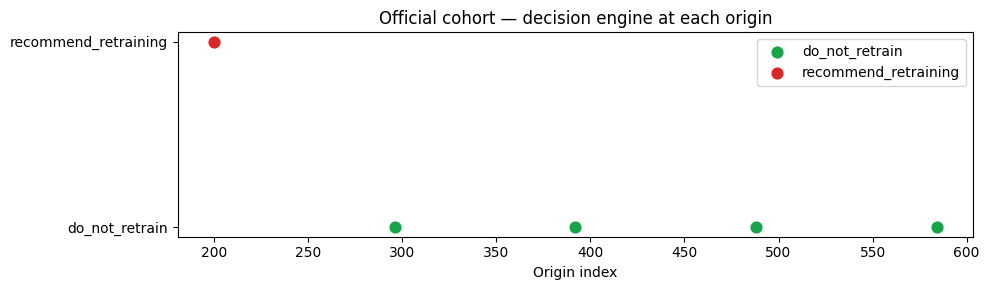

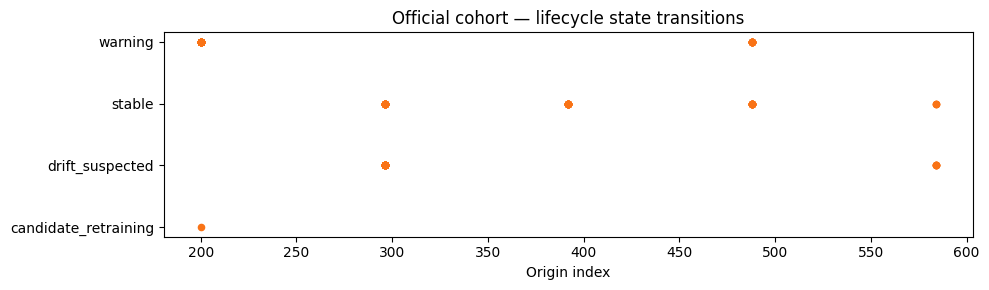

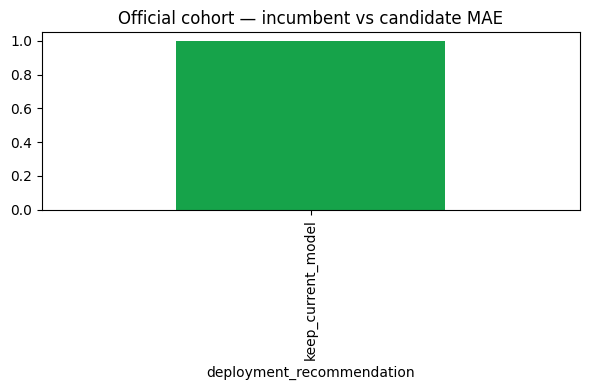

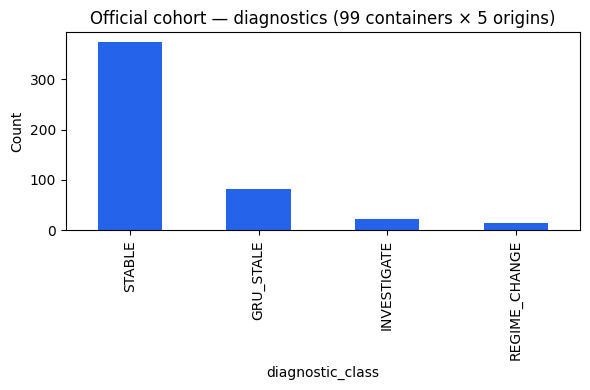

diagnostic_class
STABLE           375
GRU_STALE         82
INVESTIGATE       23
REGIME_CHANGE     15
Name: count, dtype: int64

In [11]:
fig, ax = afmlf_plots.plot_decision_timeline(decisions)
ax.set_title('Official cohort — decision engine at each origin')
plt.show()

fig, ax = afmlf_plots.plot_state_timeline(life)
ax.set_title('Official cohort — lifecycle state transitions')
plt.show()

if len(rec):
    fig, ax = afmlf_plots.plot_recommendation_quality(rec)
    ax.set_title('Official cohort — incumbent vs candidate MAE')
    plt.show()

diag_counts = diag_official['diagnostic_class'].value_counts()
fig, ax = afmlf_plots.plot_diagnostic_distribution(diag_official)
ax.set_title(f'Official cohort — diagnostics ({n_containers} containers × 5 origins)')
plt.show()
display(diag_counts)

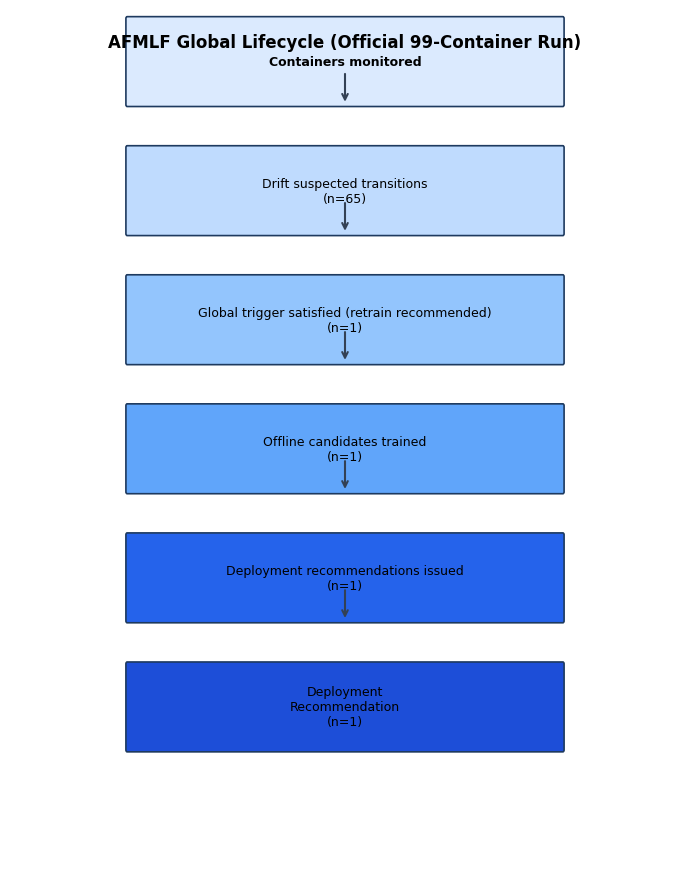


Retraining decisions are based on the monitored population, not on an individual container.
In the official run: 99 containers → 65 drift-suspected events → 1 global retrain recommendation → 1 candidate trained → 'keep_current_model' deployment recommendation.


In [12]:
def plot_afmlf_architecture_funnel(funnel_df):
    """Live matplotlib flow diagram — no external image."""
    labels = list(funnel_df['stage']) + ['Deployment\nRecommendation']
    counts = list(funnel_df['count']) + [int(funnel_df.iloc[-1]['count'])]
    colors = ['#dbeafe', '#bfdbfe', '#93c5fd', '#60a5fa', '#2563eb', '#1d4ed8']
    fig, ax = plt.subplots(figsize=(7, 9))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, len(labels) * 1.35 + 1)
    ax.axis('off')
    y = len(labels) * 1.35
    box_h, box_w = 0.9, 6.5
    x = 1.75
    for i, (label, count, color) in enumerate(zip(labels, counts, colors)):
        rect = mpatches.FancyBboxPatch((x, y), box_w, box_h, boxstyle='round,pad=0.02', fc=color, ec='#1e3a5f', lw=1.2)
        ax.add_patch(rect)
        text = label if i == 0 else f"{label}\n(n={count})"
        ax.text(x + box_w/2, y + box_h/2, text, ha='center', va='center', fontsize=9, fontweight='bold' if i==0 else 'normal')
        if i < len(labels) - 1:
            ax.annotate('', xy=(x + box_w/2, y), xytext=(x + box_w/2, y + 0.35), arrowprops=dict(arrowstyle='->', lw=1.5, color='#334155'))
        y -= 1.35
    ax.text(5, len(labels)*1.35 + 0.6, 'AFMLF Global Lifecycle (Official 99-Container Run)', ha='center', fontsize=12, fontweight='bold')
    fig.tight_layout()
    return fig, ax

fig, ax = plot_afmlf_architecture_funnel(cohort_funnel)
plt.show()

print(
    '\nRetraining decisions are based on the monitored population, not on an individual container.\n'
    f'In the official run: {n_containers} containers → {n_suspected} drift-suspected events → '
    f'{n_retrain_decisions} global retrain recommendation → {n_candidates} candidate trained → '
    f"'{rec.iloc[0]['deployment_recommendation']}' deployment recommendation."
)

## 4. Container-Level Monitoring vs Global Model Lifecycle

### Individual container (Section 2)

| Responsibility | Description |
|----------------|-------------|
| Forecasting | Walk-forward Day-1 Hybrid forecasts using history before each origin |
| Monitoring | Rolling MAE/RMSE per container |
| Drift detection | Per-container threshold breach against deployment baseline |
| Diagnostics | Prophet vs Hybrid classification (STABLE, GRU_STALE, REGIME_CHANGE, …) |
| Outcome | Container added to drift registry **or** no action |

A drifting unseen container **registers evidence** but does **not** retrain `hybrid_v1`.

### Global framework (Section 3)

| Responsibility | Description |
|----------------|-------------|
| Aggregate monitoring | Combine container-level drift evidence across the cohort |
| Global trigger policy | Cohort fraction / median degradation thresholds |
| Offline candidate retraining | Retrain global Hybrid on full train + accumulated val |
| Candidate evaluation | Compare candidate vs incumbent on future origins |
| Deployment recommendation | Deploy candidate or keep current model (human gate) |

These are **different responsibilities**. Container monitoring feeds the registry; the cohort trigger decides whether the **global** model is retrained.

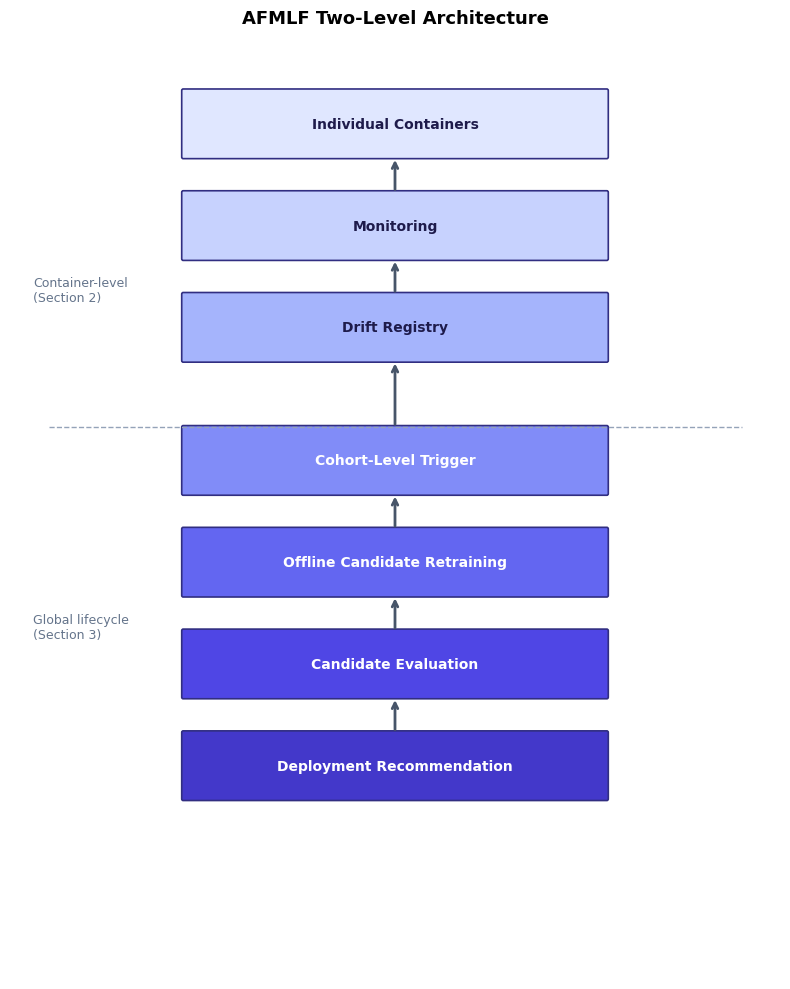

In [13]:
def plot_two_level_architecture():
    """Two-level AFMLF architecture diagram (matplotlib)."""
    fig, ax = plt.subplots(figsize=(8, 10))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 12)
    ax.axis('off')
    steps = [
        ('Individual Containers', '#e0e7ff', 10.5),
        ('Monitoring', '#c7d2fe', 9.2),
        ('Drift Registry', '#a5b4fc', 7.9),
        ('Cohort-Level Trigger', '#818cf8', 6.2),
        ('Offline Candidate Retraining', '#6366f1', 4.9),
        ('Candidate Evaluation', '#4f46e5', 3.6),
        ('Deployment Recommendation', '#4338ca', 2.3),
    ]
    box_w, box_h = 5.5, 0.85
    x = 2.25
    for i, (label, color, y) in enumerate(steps):
        rect = mpatches.FancyBboxPatch((x, y), box_w, box_h, boxstyle='round,pad=0.02', fc=color, ec='#312e81', lw=1.2)
        ax.add_patch(rect)
        ax.text(x + box_w/2, y + box_h/2, label, ha='center', va='center', fontsize=10, color='white' if i >= 3 else '#1e1b4b', fontweight='bold')
        if i < len(steps) - 1:
            y_next = steps[i+1][2] + box_h
            ax.annotate('', xy=(x + box_w/2, y), xytext=(x + box_w/2, y_next), arrowprops=dict(arrowstyle='->', lw=2, color='#475569'))
    ax.axhline(7.05, xmin=0.05, xmax=0.95, color='#94a3b8', linestyle='--', lw=1)
    ax.text(0.3, 8.8, 'Container-level\n(Section 2)', fontsize=9, color='#64748b', va='center')
    ax.text(0.3, 4.5, 'Global lifecycle\n(Section 3)', fontsize=9, color='#64748b', va='center')
    ax.set_title('AFMLF Two-Level Architecture', fontsize=13, fontweight='bold', pad=12)
    fig.tight_layout()
    return fig, ax

fig, ax = plot_two_level_architecture()
plt.show()

## 5. Key Takeaways

- **Section 2** shows container-level monitoring on two real unseen containers — stable vs drifting.
- A **single drifting container** registers in the drift registry but **does not** retrain the global Hybrid model.
- **Section 3** shows cohort-level lifecycle from the official 99-container evaluation: 65 drift-suspected events → 1 global retrain → **keep_current_model**.
- Container monitoring and global lifecycle are **separate responsibilities** in AFMLF design.
- AFMLF methodology and official experiment results were **not modified**.
- Every figure was generated **live from data** — no external images.